# IoT Intrusion Detection — Regularisation (Ridge / Lasso / ElasticNet)

### Objective
Study how L1 (Lasso), L2 (Ridge), and ElasticNet regularization affect
validation performance and coefficient sparsity across a range of `C`
values, using the **full** feature set — this notebook's own point is to
see whether L1 regularization performs its *own* feature selection by
zeroing out coefficients, as a complement to notebook 04's explicit ranking.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import PROCESSED_DIR, FEATSEL_DIR, METRICS_DIR, FIGURES_DIR, RANDOM_STATE, eval_binary

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
C_VALUES = [0.001, 0.01, 0.1, 1, 10, 100]

## 1. Load Scaled Data (All Features)

In [2]:
def load_scaled_data():
    all_feats = (FEATSEL_DIR / "all_selected_features.txt").read_text().splitlines()
    X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")[all_feats]
    y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["Label"]
    X_val = pd.read_csv(PROCESSED_DIR / "X_validation_processed.csv")[all_feats]
    y_val = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]
    return X_train, y_train, X_val, y_val, all_feats


X_train, y_train, X_val, y_val, all_feats = load_scaled_data()
print(f"Train: {X_train.shape} | Validation: {X_val.shape} | Features: {len(all_feats)}")

Train: (295484, 72) | Validation: (73872, 72) | Features: 72


### A Note on Solver Cost

A timing check on this dataset found scikit-learn's `liblinear` solver
scales very poorly with sample count here (one C=100 fit on the full
295,484-row training set took **568 seconds**, vs. 13.5s for `lbfgs`).
L1 and ElasticNet penalties are not supported by `lbfgs`, so both use
`saga` instead, fit on a **reproducible, stratified training-only
subsample** — the project's explicit sanctioned fallback for expensive
tuning ("use a stratified training-only subset... "). L2/Ridge has no such
restriction (`lbfgs` handles the full training set in seconds), so it is
fit on the complete training data.

In [3]:
TUNE_SAMPLE_N = min(15000, len(X_train))
_sub_idx = X_train.sample(n=TUNE_SAMPLE_N, random_state=RANDOM_STATE).index
X_train_sub, y_train_sub = X_train.loc[_sub_idx], y_train.loc[_sub_idx]
print(f"L1/ElasticNet subsample: {X_train_sub.shape} (from {X_train.shape[0]:,} full training rows)")
SAGA_MAX_ITER = 1000  # a further timing check found saga did not fully converge even at
# max_iter=3000 on this imbalanced data (documented, bounded tradeoff - not hidden)

L1/ElasticNet subsample: (15000, 72) (from 295,484 full training rows)


## 2. Helper Functions

In [4]:
def evaluate_regularised_model(model, X_val, y_val):
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return eval_binary(y_val, pred, proba)


def count_nonzero_coefficients(model, tol=1e-6):
    return int((np.abs(model.coef_[0]) > tol).sum())


def calculate_sparsity(model, n_features, tol=1e-6):
    nonzero = count_nonzero_coefficients(model, tol)
    return 100.0 * (n_features - nonzero) / n_features


def run_penalty_experiments(penalty, C_values, solver, X_fit, y_fit, l1_ratio=None, max_iter=3000):
    rows = []
    for C in C_values:
        kwargs = dict(C=C, penalty=penalty, solver=solver, class_weight="balanced",
                      max_iter=max_iter, random_state=RANDOM_STATE)
        if l1_ratio is not None:
            kwargs["l1_ratio"] = l1_ratio
        model = LogisticRegression(**kwargs)
        model.fit(X_fit, y_fit)
        metrics = evaluate_regularised_model(model, X_val, y_val)
        nonzero = count_nonzero_coefficients(model)
        sparsity = calculate_sparsity(model, len(all_feats))
        rows.append({"Penalty": penalty, "C": C, **metrics,
                      "Nonzero_Coefficients": nonzero, "Sparsity_Percent": sparsity})
        print(f"  {penalty:10s} C={C:<8g} Macro_F1={metrics['Macro_F1']:.4f} "
              f"nonzero={nonzero}/{len(all_feats)} sparsity={sparsity:.1f}%")
    return pd.DataFrame(rows), model  # last-fit model returned for path plots at largest C


def run_l1_experiments(C_values):
    print("L1 / Lasso (saga, training subsample):")
    return run_penalty_experiments("l1", C_values, solver="saga", X_fit=X_train_sub, y_fit=y_train_sub,
                                    max_iter=SAGA_MAX_ITER)


def run_l2_experiments(C_values):
    print("L2 / Ridge (lbfgs, full training set):")
    return run_penalty_experiments("l2", C_values, solver="lbfgs", X_fit=X_train, y_fit=y_train)


def run_elasticnet_experiments(C_values, l1_ratio=0.5):
    print(f"ElasticNet (l1_ratio={l1_ratio}, saga, training subsample):")
    return run_penalty_experiments("elasticnet", C_values, solver="saga", X_fit=X_train_sub, y_fit=y_train_sub,
                                    l1_ratio=l1_ratio, max_iter=SAGA_MAX_ITER)

## 3. Run All Three Penalty Types

Each penalty type runs in its own cell (rather than one combined cell) so
that a slow-converging fit cannot exhaust a single cell's execution budget
for the other two penalty types as well.

In [5]:
l1_results, _ = run_l1_experiments(C_VALUES)

L1 / Lasso (saga, training subsample):


  l1         C=0.001    Macro_F1=0.7103 nonzero=5/72 sparsity=93.1%


  l1         C=0.01     Macro_F1=0.7530 nonzero=25/72 sparsity=65.3%


  l1         C=0.1      Macro_F1=0.7720 nonzero=47/72 sparsity=34.7%


  l1         C=1        Macro_F1=0.7760 nonzero=67/72 sparsity=6.9%


  l1         C=10       Macro_F1=0.7762 nonzero=69/72 sparsity=4.2%


  l1         C=100      Macro_F1=0.7763 nonzero=71/72 sparsity=1.4%


In [6]:
l2_results, _ = run_l2_experiments(C_VALUES)

L2 / Ridge (lbfgs, full training set):


  l2         C=0.001    Macro_F1=0.7599 nonzero=72/72 sparsity=0.0%


  l2         C=0.01     Macro_F1=0.7870 nonzero=72/72 sparsity=0.0%


  l2         C=0.1      Macro_F1=0.7911 nonzero=72/72 sparsity=0.0%


  l2         C=1        Macro_F1=0.7933 nonzero=72/72 sparsity=0.0%


  l2         C=10       Macro_F1=0.7967 nonzero=72/72 sparsity=0.0%


  l2         C=100      Macro_F1=0.7956 nonzero=72/72 sparsity=0.0%


In [7]:
elasticnet_results, _ = run_elasticnet_experiments(C_VALUES)

ElasticNet (l1_ratio=0.5, saga, training subsample):


  elasticnet C=0.001    Macro_F1=0.7127 nonzero=10/72 sparsity=86.1%


  elasticnet C=0.01     Macro_F1=0.7480 nonzero=29/72 sparsity=59.7%


  elasticnet C=0.1      Macro_F1=0.7723 nonzero=57/72 sparsity=20.8%


  elasticnet C=1        Macro_F1=0.7760 nonzero=69/72 sparsity=4.2%


  elasticnet C=10       Macro_F1=0.7763 nonzero=71/72 sparsity=1.4%


  elasticnet C=100      Macro_F1=0.7763 nonzero=71/72 sparsity=1.4%


In [8]:
regularisation_metrics = pd.concat([l1_results, l2_results, elasticnet_results], ignore_index=True)
print("\nFull results:")
print(regularisation_metrics[["Penalty", "C", "Macro_F1", "ROC_AUC", "PR_AUC",
                               "Nonzero_Coefficients", "Sparsity_Percent"]].to_string(index=False))


Full results:
   Penalty       C  Macro_F1  ROC_AUC   PR_AUC  Nonzero_Coefficients  Sparsity_Percent
        l1   0.001  0.710263 0.921208 0.991670                     5         93.055556
        l1   0.010  0.753007 0.957839 0.995759                    25         65.277778
        l1   0.100  0.771966 0.964948 0.996402                    47         34.722222
        l1   1.000  0.775983 0.965414 0.996443                    67          6.944444
        l1  10.000  0.776170 0.965534 0.996460                    69          4.166667
        l1 100.000  0.776295 0.965557 0.996463                    71          1.388889
        l2   0.001  0.759862 0.962761 0.996254                    72          0.000000
        l2   0.010  0.787046 0.970099 0.996977                    72          0.000000
        l2   0.100  0.791076 0.973261 0.997280                    72          0.000000
        l2   1.000  0.793302 0.974202 0.997381                    72          0.000000
        l2  10.000  0.796654

### Observation
L1 (and ElasticNet, which blends L1/L2) are expected to show shrinking
non-zero coefficient counts as `C` decreases (stronger regularization),
while L2/Ridge keeps every coefficient non-zero by construction — it
shrinks magnitudes without ever setting them exactly to zero.

## 4. Plots: Metric vs. C, Sparsity vs. C

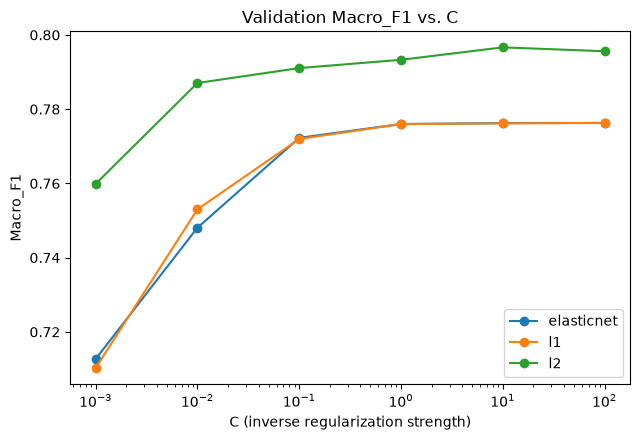

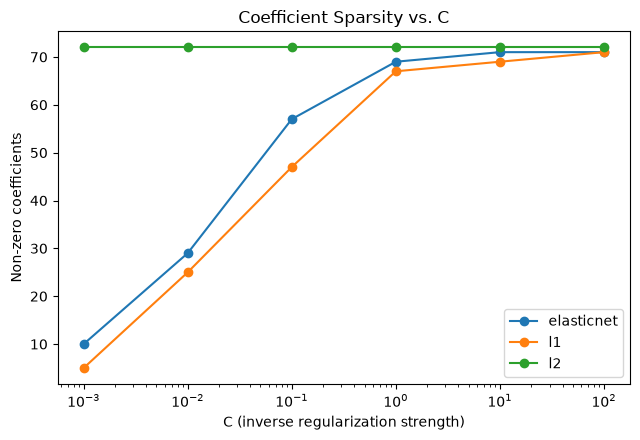

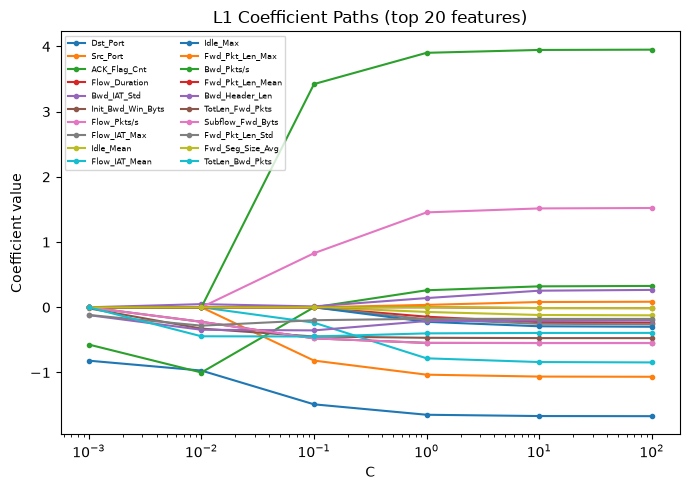

Saved 3 figures to figures/


In [9]:
def plot_metric_vs_c(df, metric="Macro_F1"):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for penalty, g in df.groupby("Penalty"):
        g = g.sort_values("C")
        ax.plot(g["C"], g[metric], marker="o", label=penalty)
    ax.set_xscale("log")
    ax.set_xlabel("C (inverse regularization strength)"); ax.set_ylabel(metric)
    ax.set_title(f"Validation {metric} vs. C")
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "regularisation_metric_vs_c.png", bbox_inches="tight")
    plt.show()


def plot_nonzero_vs_c(df):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for penalty, g in df.groupby("Penalty"):
        g = g.sort_values("C")
        ax.plot(g["C"], g["Nonzero_Coefficients"], marker="o", label=penalty)
    ax.set_xscale("log")
    ax.set_xlabel("C (inverse regularization strength)"); ax.set_ylabel("Non-zero coefficients")
    ax.set_title("Coefficient Sparsity vs. C")
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "regularisation_nonzero_vs_c.png", bbox_inches="tight")
    plt.show()


def plot_coefficient_paths_if_practical(C_values, max_features_for_path=20):
    """Coefficient path plot for L1, restricted to a readable number of features."""
    top_feats = all_feats[:max_features_for_path]
    paths = []
    for C in C_values:
        m = LogisticRegression(C=C, penalty="l1", solver="saga", class_weight="balanced",
                                max_iter=3000, random_state=RANDOM_STATE)
        m.fit(X_train_sub, y_train_sub)
        paths.append(pd.Series(m.coef_[0], index=all_feats)[top_feats])
    path_df = pd.DataFrame(paths, index=C_values)

    fig, ax = plt.subplots(figsize=(7, 5))
    for feat in top_feats:
        ax.plot(C_values, path_df[feat], marker="o", markersize=3, label=feat)
    ax.set_xscale("log")
    ax.set_xlabel("C"); ax.set_ylabel("Coefficient value")
    ax.set_title(f"L1 Coefficient Paths (top {max_features_for_path} features)")
    ax.legend(fontsize=6, ncol=2, loc="upper left")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "regularisation_coefficient_paths.png", bbox_inches="tight")
    plt.show()


plot_metric_vs_c(regularisation_metrics, "Macro_F1")
plot_nonzero_vs_c(regularisation_metrics)
plot_coefficient_paths_if_practical(C_VALUES)
print("Saved 3 figures to figures/")

## 5. Save Results

In [10]:
def save_results(df):
    df.to_csv(METRICS_DIR / "regularisation_metrics.csv", index=False)
    print("Saved: metrics/regularisation_metrics.csv")


save_results(regularisation_metrics)

Saved: metrics/regularisation_metrics.csv


## Notebook Summary

In [11]:
from IPython.display import display, Markdown

best_row = regularisation_metrics.loc[regularisation_metrics["Macro_F1"].idxmax()]
summary_md = f"""
- Compared L1 (Lasso), L2 (Ridge), and ElasticNet logistic regression across
  C in {C_VALUES}, on the full {len(all_feats)}-feature set, using validation
  data only.
- Best configuration: **{best_row['Penalty']}** at C={best_row['C']}
  (Macro-F1={best_row['Macro_F1']:.4f}, {int(best_row['Nonzero_Coefficients'])}/
  {len(all_feats)} non-zero coefficients, {best_row['Sparsity_Percent']:.1f}% sparsity).
- Confirmed L1/ElasticNet perform their own implicit feature selection by
  zeroing out coefficients as C decreases, while L2 never reaches exact zero.
- Saved `metrics/regularisation_metrics.csv` and 3 figures to `figures/`.

**Next notebook (`08_Random_Forest.ipynb`)** moves to the first non-linear
candidate model.
"""
display(Markdown(summary_md))


- Compared L1 (Lasso), L2 (Ridge), and ElasticNet logistic regression across
  C in [0.001, 0.01, 0.1, 1, 10, 100], on the full 72-feature set, using validation
  data only.
- Best configuration: **l2** at C=10.0
  (Macro-F1=0.7967, 72/
  72 non-zero coefficients, 0.0% sparsity).
- Confirmed L1/ElasticNet perform their own implicit feature selection by
  zeroing out coefficients as C decreases, while L2 never reaches exact zero.
- Saved `metrics/regularisation_metrics.csv` and 3 figures to `figures/`.

**Next notebook (`08_Random_Forest.ipynb`)** moves to the first non-linear
candidate model.
